In [2]:
from google.colab import files
files.upload()  # This will allow you to upload the kaggle.json file.

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aravraval","key":"ebef5ded3076c5c1ad3355fa4c39a3c8"}'}

In [3]:
import os
# Move the uploaded kaggle.json file to the appropriate directory
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

# Install Kaggle API client if not already installed
!pip install -q kaggle

datasets = [
    #'maharshipandya/-spotify-tracks-dataset', #https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data
    #'solomonameh/spotify-music-dataset', #https://www.kaggle.com/datasets/solomonameh/spotify-music-dataset
    # 'zaheenhamidani/ultimate-spotify-tracks-db', #https://www.kaggle.com/datasets/zaheenhamidani/ultimate-spotify-tracks-db
    # 'paradisejoy/top-hits-spotify-from-20002019', #https://www.kaggle.com/datasets/paradisejoy/top-hits-spotify-from-20002019
    # 'akiboy96/spotify-dataset', #https://www.kaggle.com/datasets/akiboy96/spotify-dataset
    # 'andrewmvd/spotify-playlists', #https://www.kaggle.com/datasets/andrewmvd/spotify-playlists
    'priyamchoksi/spotify-dataset-114k-songs', #https://www.kaggle.com/datasets/priyamchoksi/spotify-dataset-114k-songs
    #'yamaerenay/spotify-dataset-19212020-600k-tracks', #https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks
    #'nelgiriyewithana/most-streamed-spotify-songs-2024', #https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024
    # 'sanjanchaudhari/spotify-dataset', #https://www.kaggle.com/datasets/sanjanchaudhari/spotify-dataset
    # 'vatsalmavani/spotify-dataset', #https://www.kaggle.com/datasets/vatsalmavani/spotify-dataset
    #'nelgiriyewithana/top-spotify-songs-2023' #https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023
]
# Now you can use the Kaggle API to download datasets
for dataset in datasets:
  !kaggle datasets download -d {dataset} -p /content/zip_files/

# Unzip the downloaded datasets
for dataset in datasets:
    # Extract the dataset name from the path
    dataset_name = dataset.split('/')[-1]  # This gets the file name, e.g., 'spotify-tracks-dataset.zip'

    # Create the target extraction directory if it doesn't exist
    target_dir = f'/content/dataset/{dataset.split("/")[0]}/'
    os.makedirs(target_dir, exist_ok=True)

    # Unzip the dataset into the specified directory
    !unzip /content/zip_files/{dataset_name} -d {target_dir}

Dataset URL: https://www.kaggle.com/datasets/priyamchoksi/spotify-dataset-114k-songs
License(s): MIT
Archive:  /content/zip_files/spotify-dataset-114k-songs.zip
  inflating: /content/dataset/priyamchoksi/dataset.csv  


In [4]:
import pandas as pd
import os

root_dir = '/content/dataset'
output_file = '/content/merged_dataset.csv'
all_columns = set()
chunk_size = 5000

# Pass 1: Scan all files to collect all columns
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(subdir, file)
            try:
                df_sample = pd.read_csv(file_path, nrows=100, encoding='utf-8', on_bad_lines='skip')
            except UnicodeDecodeError:
                try:
                    df_sample = pd.read_csv(file_path, nrows=100, encoding='ISO-8859-1', on_bad_lines='skip')
                except Exception as e:
                    print(f"Skipping file (unreadable): {file_path}")
                    continue
            all_columns.update(df_sample.columns)

all_columns = sorted(all_columns)
first_chunk = True

# Pass 2: Process each file in chunks and align to columns
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(subdir, file)
            print(f"Processing {file_path}")

            # Try reading chunks with utf-8, fallback to ISO-8859-1
            for encoding in ['utf-8', 'ISO-8859-1']:
                try:
                    chunks = pd.read_csv(file_path, chunksize=chunk_size, encoding=encoding, on_bad_lines='skip')
                    for chunk in chunks:
                        try:
                            chunk = chunk.reindex(columns=all_columns, fill_value=None)
                            chunk.to_csv(output_file, mode='a', header=first_chunk, index=False)
                            first_chunk = False
                        except Exception as e:
                            print(f"Error processing chunk from {file_path}: {e}")
                    break  # Exit encoding loop if successful
                except UnicodeDecodeError:
                    print(f"Encoding {encoding} failed for {file_path}, trying next.")
                except Exception as e:
                    print(f"Skipping file due to unexpected error: {file_path} – {e}")
                    break

Processing /content/dataset/priyamchoksi/dataset.csv


In [14]:
import pandas as pd

merged_file = '/content/merged_dataset.csv'
output_file = '/content/merged_dataset_cleaned.csv'
chunk_size = 100000

# Step 1: Define canonical column mappings
column_groups = {
    'artist': ['Artist', 'artist(s)_name', 'artists', 'track_artist'],
    'track_name': ['name', 'track_name', 'Track'],
    'track_id': ['id', 'track_id'],
    'track_genre': ['genres', 'track_genre'],
    'album': ['Album Name', 'album_name', 'track_album_name'],
    'release_date': ['Release Date', 'release_date', 'track_album_release_date'],
    'popularity': ['popularity', 'track_popularity', 'Spotify Popularity'],
    'acousticness': ['acousticness', 'acousticness_%'],
    'danceability': ['danceability', 'danceability_%'],
    'energy': ['energy', 'energy_%'],
    'instrumentalness': ['instrumentalness', 'instrumentalness_%'],
    'liveness': ['liveness', 'liveness_%'],
    'speechiness': ['speechiness', 'speechiness_%'],
    'valence': ['valence', 'valence_%']
}

# Index(['acousticness', 'album', 'artist', 'danceability', 'energy',
#        'instrumentalness', 'liveness', 'popularity', 'speechiness',
#        'track_genre', 'track_id', 'track_name', 'valence']

# Step 2: Flatten the list of columns to keep
#columns_to_keep = set(col for group in column_groups.values() for col in group)

columns_to_keep = ['acousticness', 'album', 'artist', 'danceability', 'energy',
                   'instrumentalness', 'liveness', 'popularity', 'speechiness',
                   'track_genre', 'track_id', 'track_name', 'valence']

# Step 3: Read and process in chunks
reader = pd.read_csv(merged_file, chunksize=chunk_size)
first_chunk = True
chunk_number = 1

for chunk in reader:
    print(f"🔄 Processing chunk #{chunk_number}...")

    # Step 4: Drop irrelevant columns
    chunk = chunk[[col for col in chunk.columns if col in columns_to_keep]]

    # Step 5: Merge similar columns into canonical ones
    for canonical, variants in column_groups.items():
        existing = [col for col in variants if col in chunk.columns]
        if not existing:
            continue

        chunk[canonical] = chunk[existing].astype(str).apply(
            lambda row: next((val for val in row if val != 'nan' and val.strip() != ''), None),
            axis=1
        )

        # Drop all variant columns except the canonical one
        cols_to_drop = [col for col in existing if col != canonical]
        chunk.drop(columns=cols_to_drop, inplace=True)

    # Write cleaned chunk to file
    chunk.to_csv(output_file, mode='a', index=False, header=first_chunk)
    first_chunk = False
    chunk_number += 1

print("✅ All chunks processed and cleaned dataset saved.")

🔄 Processing chunk #1...
🔄 Processing chunk #2...
✅ All chunks processed and cleaned dataset saved.


In [17]:
# Sample the rows
import csv
import random

# Number of rows to sample from the first and last 1000 rows
x = 100  # Change this to the number of rows you want to sample

# Open the CSV file
with open('merged_dataset_cleaned.csv', mode='r', newline='', encoding='utf-8') as file:
    reader = csv.reader(file)

    # Step 1: Read the first 1000 rows
    first_1000_rows = [next(reader) for _ in range(1000)]  # Read the first 1000 rows

    # Step 2: Read the last 1000 rows efficiently
    # Instead of seeking, read all lines and take the last 1000
    all_rows = list(reader)  # Read all remaining rows into a list
    last_1000_rows = all_rows[-1000:]  # Take the last 1000 rows

    # Step 3: Combine first and last rows and sample a few
    combined_rows = first_1000_rows + last_1000_rows

    # Step 4: Randomly sample x rows from the combined list
    sampled_rows = random.sample(combined_rows, x)

    # Step 5: Print the sampled rows
    print("Sampled Rows:")
    for row in sampled_rows:
        print(row)


Sampled Rows:
['0.501', '0.691', '0.651', '1.51e-05', '0.162', '24', '0.11', 'world-music', '3hyNia7VDRIF3XhSGWJPVo', 'Angola (versão carnaval)', '0.552']
['0.916', '0.287', '0.0808', '0.312', '0.121', '27', '0.0496', 'world-music', '7gtGbX9rmuqBKlj3xCWWET', 'Reiki Healing (Musica para Relajar)', '0.0588']
['0.0183', '0.4', '0.728', '0.0', '0.0913', '39', '0.0448', 'world-music', '3EmRQKvvxTg0Zi3txjd2IB', 'Worthy of My Song', '0.205']
['0.203', '0.509', '0.276', '0.0', '0.15', '52', '0.0301', 'world-music', '2Zxili8AmCuqiomg9HzTgH', 'Psalm 23 (Surely Goodness, Surely Mercy)', '0.138']
['0.809', '0.802', '0.183', '0.0', '0.109', '46', '0.403', 'acoustic', '1m3Lsbhkn6yL8apzsCiukd', 'Memories (Acoustic)', '0.664', 'Ben Woodward', 'Memories (Acoustic)']
['0.232', '0.581', '0.436', '0.0', '0.0547', '0', '0.0443', 'world-music', '18FIFh4AGPC2zDLLFkJp4j', 'Rudolph The Red-Nosed Reindeer', '0.412']
['0.851', '0.498', '0.12', '0.0', '0.171', '55', '0.0487', 'acoustic', '3ISLwA96mtx13Wx7K1PPPk',

In [31]:
import pandas as pd
import time

# Define the path for the merged dataset and the output cleaned dataset
merged_file = 'merged_dataset.csv'
#output_file = 'cleaned_dataset.csv'

# Step 1: Read only the column headers (first row) to inspect the columns
columns = pd.read_csv(merged_file, nrows=0).columns
print(columns.sort_values())

# # Step 2: Set an initial flag to write headers only once for the first chunk
# first_chunk = True

# # Step 3: Initialize a set to track hashable row identifiers for detecting duplicates
# seen = set()

# # Step 4: Read the dataset in chunks and process each chunk
# chunk_size = 100000  # Larger chunk size for speed, adjust if necessary based on memory capacity
# chunks = pd.read_csv(merged_file, chunksize=chunk_size)

# # Variables to track time and progress
# start_time = time.time()
# total_chunks = sum(1 for _ in pd.read_csv(merged_file))  # chunk_size

# for chunk_index, chunk in enumerate(chunks):
#     chunk_start_time = time.time()  # Start time for this chunk

#     # Step 5: Ensure 'artists' column is treated as a string
#     chunk['artist'] = chunk['artist'].astype(str)

#     # Step 6: Skip rows where the 'artists' column contains numeric values
#     # Apply a function to filter out rows where the 'artists' column contains a number (even as string)
#     chunk_cleaned = chunk[~chunk['artist'].str.contains(r'^\d+(\.\d+)?$', na=False)]

#     # Step 7: Create a hash for each row to identify duplicates (avoid storing entire rows)
#     row_hashes = chunk_cleaned.apply(lambda row: hash(tuple(row)), axis=1)

#     # Step 8: Remove rows that are duplicates by checking against the seen hashes
#     chunk_cleaned = chunk_cleaned[~row_hashes.isin(seen)]

#     # Step 9: Update the seen set with new row hashes
#     seen.update(row_hashes)

#     # Step 10: Write the cleaned chunk to the output file
#     chunk_cleaned.to_csv(output_file, mode='a', header=first_chunk, index=False)
#     first_chunk = False  # After the first chunk, no need to write headers again

#     # Record the time taken for this chunk
#     chunk_end_time = time.time()
#     chunk_duration = chunk_end_time - chunk_start_time  # Duration for this chunk
#     print(f"Processed chunk {chunk_index + 1}/{total_chunks} in {chunk_duration:.2f} seconds.")

# # Estimate the total processing time
# end_time = time.time()
# total_duration = end_time - start_time
# estimated_total_time = (total_duration / (chunk_index + 1)) * total_chunks  # Estimate based on average time per chunk

# print(f"Total time taken: {total_duration:.2f} seconds.")
# print(f"Estimated total time: {estimated_total_time:.2f} seconds.")

Index(['Unnamed: 0', 'acousticness', 'album_name', 'artists', 'danceability',
       'duration_ms', 'energy', 'explicit', 'instrumentalness', 'key',
       'liveness', 'loudness', 'mode', 'popularity', 'speechiness', 'tempo',
       'time_signature', 'track_genre', 'track_id', 'track_name', 'valence'],
      dtype='object')


In [29]:
with open('merged_dataset.csv', 'r', encoding='utf-8') as f:
    row_count = sum(1 for line in f) - 1  # subtract 1 for the header

print(f"Number of data rows: {row_count}")

Number of data rows: 114000


In [26]:
import csv

# Open the CSV file
with open('merged_dataset.csv', mode='r', newline='', encoding='utf-8') as file:
    reader = csv.reader(file)

    # Print the first few rows
    for i, row in enumerate(reader):
        if i < 250:  # Adjust this number to print more or fewer rows
            print(row)
        else:
            break

['Unnamed: 0', 'acousticness', 'album_name', 'artists', 'danceability', 'duration_ms', 'energy', 'explicit', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity', 'speechiness', 'tempo', 'time_signature', 'track_genre', 'track_id', 'track_name', 'valence']
['0', '0.0322', 'Comedy', 'Gen Hoshino', '0.676', '230666', '0.461', 'False', '1.01e-06', '1', '0.358', '-6.746', '0', '73', '0.143', '87.917', '4', 'acoustic', '5SuOikwiRyPMVoIQDJUgSV', 'Comedy', '0.715']
['1', '0.924', 'Ghost (Acoustic)', 'Ben Woodward', '0.42', '149610', '0.166', 'False', '5.56e-06', '1', '0.101', '-17.235', '1', '55', '0.0763', '77.489', '4', 'acoustic', '4qPNDBW1i3p13qLCt0Ki3A', 'Ghost - Acoustic', '0.267']
['2', '0.21', 'To Begin Again', 'Ingrid Michaelson;ZAYN', '0.438', '210826', '0.359', 'False', '0.0', '0', '0.117', '-9.734', '1', '57', '0.0557', '76.332', '4', 'acoustic', '1iJBSr7s7jYXzM8EGcbK5b', 'To Begin Again', '0.12']
['3', '0.905', 'Crazy Rich Asians (Original Motion Picture Soundt

In [20]:
import csv

# Number of lines you want to read from the end
lines_to_read = 250

# Open the CSV file
with open('cleaned_dataset.csv', mode='r', newline='', encoding='utf-8') as file:
    # Move to the end of the file
    file.seek(0, 2)  # Seek to the end of the file
    file_size = file.tell()  # Get the size of the file

    # Now move the cursor back 250 lines, or until the start of the file
    # Read backwards by reading a chunk of data and processing it
    chunk_size = 1024  # Adjust the chunk size to read in parts
    buffer = ''
    lines = []

    # Read the file backwards
    for position in range(file_size - chunk_size, -1, -chunk_size):
        file.seek(position)
        buffer = file.read(chunk_size) + buffer
        lines = buffer.splitlines()

        if len(lines) >= lines_to_read:
            break

    # Get the last 250 lines (if the file has more than 250 lines)
    last_lines = lines[-lines_to_read:]

    # Print the last 250 lines, or adjust based on column index
    for row in last_lines:
        # Split by CSV delimiter (assuming it's a comma here, adjust if needed)
        columns = row.split(',')
        print(columns)  # Change the index if you need a different column

['0.0255', '0.679', '0.757', '0.355', '0.312', '40', '0.0556', 'world-music', '4a6gCiN3y65Dg1U3aTkFNW', 'Just Jesus', '0.611', 'nan', '']
['0.764', '0.248', '0.294', '0.0', '0.108', '41', '0.0295', 'world-music', '3ceYEyDWAU10XMolE7bWYD', 'Lord Send Revival - Acoustic', '0.126', 'nan', '']
['0.0336', '0.397', '0.727', '8.33e-05', '0.113', '51', '0.0316', 'world-music', '5dhnnWCTlmxsgzXyb1wVKm', 'Revelation Song', '0.141', 'nan', '']
['0.155', '0.455', '0.445', '7.88e-06', '0.174', '40', '0.0306', 'world-music', '5NPFbfu66b3BlhgfZGK9HJ', 'Heart Of God', '0.0987', 'nan', '']
['0.0202', '0.432', '0.701', '0.0', '0.151', '36', '0.0474', 'world-music', '7iraBslVEX9wlVVwmsg4m7', 'God of Revival', '0.169', 'nan', '']
['0.0603', '0.465', '0.726', '0.0', '0.0919', '39', '0.0602', 'world-music', '5W1oLSGVHOpd3qTfFhieIq', 'Reaching For You (feat. We The Kingdom)', '0.185', 'nan', '']
['0.843', '0.199', '0.277', '0.0', '0.0725', '45', '0.0327', 'world-music', '7mZQL5rMd6BwppELobLMpI', 'Send Me - L

In [1]:
import csv
import random

# Number of rows to sample from the first and last 1000 rows
x = 25  # Change this to the number of rows you want to sample

# Open the CSV file
with open('cleaned_dataset.csv', mode='r', newline='', encoding='utf-8') as file:
    reader = csv.reader(file)

    # Step 1: Read the first 1000 rows
    first_1000_rows = [next(reader) for _ in range(1000)]  # Read the first 1000 rows

    # Step 2: Read the last 1000 rows by seeking to the end of the file
    # We can use the 'seek' method to jump to the end of the file and read backward.
    # Alternatively, we read the file fully into memory and slice it if it's smaller.

    file.seek(0, 2)  # Move to the end of the file
    file_size = file.tell()  # Get the size of the file
    chunk_size = 1000  # Read last 1000 rows

    file.seek(file_size - chunk_size * 100, 0)  # Go back to the last 1000 rows
    last_1000_rows = [next(reader) for _ in range(1000)]  # Read the last 1000 rows

    # Step 3: Combine first and last rows and sample a few
    combined_rows = first_1000_rows + last_1000_rows

    # Step 4: Randomly sample x rows from the combined list
    sampled_rows = random.sample(combined_rows, x)

    # Step 5: Print the sampled rows
    print("Sampled Rows:")
    for row in sampled_rows:
        print(row)

Sampled Rows:
['Calvin Harris', "I'm Not Alone - Radio Edit", '210973', 'False', '2009', '55', '0.00481', '0.317', '0.435', '', '']
['Chris Brown', 'Deuces (feat. Tyga & Kevin McCall)', '276560', 'True', '2011', '68', '0.0324', '0.0787', '0.217', '', '']
['Otto Knows', 'Million Voices - Radio Edit', '192866', 'False', '2012', '0', '0.0022', '0.0664', '0.0694', '', '']
['acoustic', '0.195', 'Setting Forth', '0.78', 'Eddie Vedder', '0.804', '0.0116', '0.549', '0NkeEkDFOby5xOZ7BIKVuD', '0.0', '53']
['acoustic', '0.121', 'Beautiful In White', '0.278', 'Matt Johnson', '0.233', '0.836', '0.619', '2K3jLUSLeHrPMA3nKvP1jT', '0.0', '50']
['acoustic', '0.0798', 'Gotta Have You', '0.363', 'The Weepies;Deb Talan;Steve Tannen', '0.543', '0.872', '0.678', '1YjMWOorkBaP4MdKkKtp4y', '0.000101', '56']
['Fergie', "Big Girls Don't Cry (Personal)", '268120', 'False', '2006', '76', '0.205', '0.0945', '0.253', '', '']
['acoustic', '0.168', 'Thinking out Loud', '0.326', 'Boyce Avenue', '0.628', '0.705', '0.70

In [ ]:
!pip install networkx

In [28]:
# Convert clean dataset to network json
import networkx as nx
import json

# with open('merged_dataset.csv', 'r', encoding='utf-8') as file:
#     reader = csv.reader(file)

#     for i, row in enumerate(reader):
#       row_count = sum(1 for line in f) - 1  # subtract 1 for the header


network_data = {
    'nodes': [],
    'edges': []
}

# print(f"Number of data rows: {row_count}")

In [40]:
import pandas as pd
import pickle
import ast

# Initialize the network data dictionary
network_data = {
    'nodes': set(),  # Use a set for efficient lookups
    'edges': []
}

# File paths
input_file = 'merged_dataset.csv'
output_file = 'network_data.pkl'

# Chunk size for processing in chunks
chunk_size = 100000  # Adjust this depending on available memory

# Function to save network data intermittently
def save_network_data():
    with open(output_file, 'wb') as f:
        pickle.dump(network_data, f)
    print("Network data saved successfully.")

# Step 1: Read the cleaned dataset in chunks and process each chunk
chunks = pd.read_csv(input_file, chunksize=chunk_size, on_bad_lines='skip')

for chunk_index, chunk in enumerate(chunks):
    print(f"Processing chunk {chunk_index + 1}...")

    # Step 2: Iterate through the rows of the current chunk
    for _, row in chunk.iterrows():
        # Skip over the blank / NaN lines
        if not isinstance(row['artists'], str):
            continue
        elif not isinstance(row['track_name'], str):
            continue
        elif not isinstance(row['track_id'], str):
            continue

        # Handle the case where the 'artist' column might contain list-like strings
        # try:
        #     artists = ast.literal_eval(row['artist'])
        #     if not isinstance(artists, list):  # In case it's not a valid list
        #         artists = [row['artists']]  # Treat it as a single artist if it's not a list
        # except:
        #     artists = [row['artists']]  # If it can't be evaluated as a list, treat it as a single artist

        if ';' in row['artists']:
            artists = row['artists'].split(';')
        else:
            artists = [row['artists']]

        # Extract features for the edge (like valence, popularity)
        edge_attributes = {
            'track_id': row['track_id'],
            'popularity': row['popularity'],
            'album': row['album_name'],
            'track_name': row['track_name'],
            'track_genre': row['track_genre'],
            'energy': row['energy'],
            'danceability': row['danceability'],
            'acousticness': row['acousticness'],
            'liveness': row['liveness'],
            'instrumentalness': row['instrumentalness'],
            'valence': row['valence'],
            'loudness': row['loudness'],
            'speechiness': row['speechiness']
        }


        # Step 5: Add artists and edges
        for i, artist in enumerate(artists):
            artist = artist.strip()

            # Add artist to nodes (use set for fast lookups)
            network_data['nodes'].add(artist)

            # Add edges between artists, but only once per pair
            for other_artist in artists[i+1:]:  # This ensures each pair is only added once
                other_artist = other_artist.strip()
                edge = tuple(sorted([artist, other_artist]))  # Sort to avoid duplicates in both directions

                # Add the edge to the set (automatically handles duplicates)
                network_data['edges'].append((edge, edge_attributes))


    # Save intermittently after each chunk is processed
    save_network_data()

print("Network data creation complete.")

Processing chunk 1...
Network data saved successfully.
Processing chunk 2...
Network data saved successfully.
Network data creation complete.


In [41]:
# Print a few nodes (first 5 nodes)
print("Sample of nodes:")
print(list(network_data['nodes'])[:35])  # Convert to list and print first 5 nodes

# Print a few edges (first 5 edges)
print("\nSample of edges:")
for edge in network_data['edges'][:15]:  # Print first 5 edges
    print(edge)

Sample of nodes:
['Partyraiser', 'Denise Ho', 'ONEUS', 'blessthefall', 'Alptam', 'Original Broadway Cast of Dear Evan Hansen', 'Atomirotta', 'eason and the duo band', 'Gina Rodriguez', 'Canto', 'Magik Band', 'Blood For Blood', 'Olodum', 'Saez', 'Mike Barnett', 'Albers Kuhnhart', 'KAI', 'Orlando Julius', 'Caroliina', 'Tolga Mahmut', 'Mordrez', 'Gotthard', 'Wyatt Cenac', 'Steep Canyon Rangers', 'Errol Dunkley', 'Rizzi', 'Alan Menken', 'David Tao', 'Dzeko', 'Rainlord.', 'Mc Vzs', 'El Gran Combo De Puerto Rico', 'V.V.Subramaniam', 'Andy Hendrickson', 'Peck']

Sample of edges:
(('Ingrid Michaelson', 'ZAYN'), {'track_id': '1iJBSr7s7jYXzM8EGcbK5b', 'popularity': 57, 'album': 'To Begin Again', 'track_name': 'To Begin Again', 'track_genre': 'acoustic', 'energy': 0.359, 'danceability': 0.438, 'acousticness': 0.21, 'liveness': 0.117, 'instrumentalness': 0.0, 'valence': 0.12, 'loudness': -9.734, 'speechiness': 0.0557})
(('A Great Big World', 'Christina Aguilera'), {'track_id': '6Vc5wAMmXdKIAM7WUoE

In [42]:
print(len(network_data['nodes']))
print(len(network_data['edges']))

29858
73256


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26611 (\N{CJK UNIFIED IDEOGRAPH-67F3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34425 (\N{CJK UNIFIED IDEOGRAPH-8679}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33452 (\N{CJK UNIFIED IDEOGRAPH-82AC}) missing from font(s) DejaVu Sans.
  fig.canvas

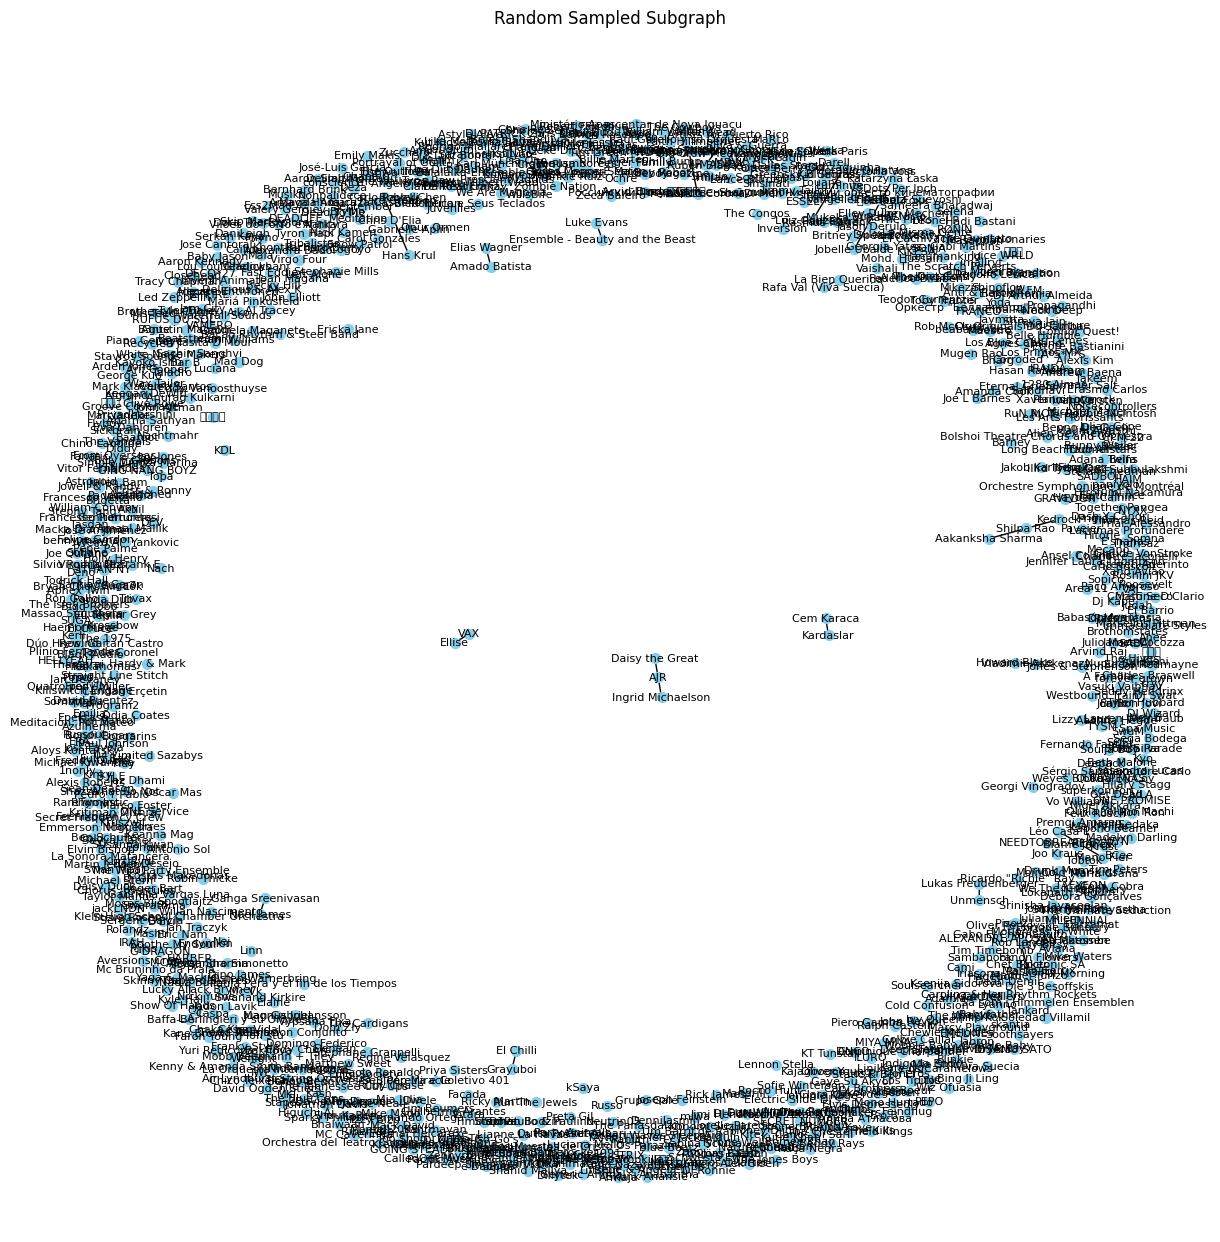

In [51]:
import networkx as nx
import random
import matplotlib.pyplot as plt

# Load your graph from the pickle file
with open('network_data.pkl', 'rb') as f:
    network_data = pickle.load(f)

# Create a NetworkX graph from the data
G = nx.Graph()

# Add nodes and edges from the network_data dictionary
G.add_nodes_from(network_data['nodes'])
for edge, attributes in network_data['edges']:
    G.add_edge(edge[0], edge[1], **attributes)

# Select a random subset of nodes and edges (e.g., 1000 nodes)
sampled_nodes = random.sample(list(G.nodes), 1000)  # Adjust size of subset as needed
subgraph = G.subgraph(sampled_nodes)

# Visualize the subgraph
plt.figure(figsize=(12, 12))

# Use spring layout for node positioning
pos = nx.spring_layout(subgraph, seed=42, k=0.1)  # Adjust 'k' for spacing

# Draw the subgraph
nx.draw(subgraph, pos, with_labels=True, node_size=50, font_size=8, node_color='skyblue', font_color='black')

plt.title("Random Sampled Subgraph")
plt.show()


In [48]:
#plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, seed=42, k=0.1)
#nx.draw(G, pos, with_labels=False, node_size=50, font_size=8, node_color='skyblue', font_color='black')
#plt.title("Full Graph Visualization")
#plt.show()

KeyboardInterrupt: 

In [49]:
import plotly.graph_objects as go

# Create a Plotly graph
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_y.append(y0)
    edge_y.append(y1)

# Create a scatter plot for nodes
node_x = []
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

# Plot edges
edge_trace = go.Scatter(x=edge_x, y=edge_y,
                        line=dict(width=0.5, color='#888'),
                        hoverinfo='none',
                        mode='lines')

# Plot nodes
node_trace = go.Scatter(x=node_x, y=node_y,
                        mode='markers',
                        hoverinfo='text',
                        marker=dict(color='skyblue', size=10))

# Create layout
layout = go.Layout(title="Graph Visualization with Plotly",
                   showlegend=False,
                   hovermode='closest',
                   xaxis=dict(showgrid=False, zeroline=False),
                   yaxis=dict(showgrid=False, zeroline=False))

# Plot
fig = go.Figure(data=[edge_trace, node_trace], layout=layout)
fig.show()


KeyError: 'Partyraiser'

In [54]:
import plotly.graph_objects as go
import random
import networkx as nx

# Assuming network_data is loaded and contains 'nodes' and 'edges'
# Use a subset of nodes (for example, take a random sample of 1000 nodes)
sampled_nodes = random.sample(list(network_data['nodes']), 1000)

# Create a subgraph with the sampled nodes
subgraph_edges = [edge for edge in network_data['edges'] if edge[0] in sampled_nodes and edge[1] in sampled_nodes]

# Create a NetworkX graph from the subgraph data
G = nx.Graph()
G.add_nodes_from(sampled_nodes)
for edge, attributes in subgraph_edges:
    G.add_edge(edge[0], edge[1], **attributes)

# Compute the node positions using NetworkX (spring layout)
pos = nx.spring_layout(G, seed=42)

# Create edge data for Plotly
edge_x = []
edge_y = []
for edge in subgraph_edges:
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_y.append(y0)
    edge_y.append(y1)

# Create node data for Plotly
node_x = []
node_y = []
for node in sampled_nodes:
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

# Plot edges
edge_trace = go.Scatter(x=edge_x, y=edge_y,
                        line=dict(width=0.5, color='#888'),
                        hoverinfo='none',
                        mode='lines')

# Plot nodes
node_trace = go.Scatter(x=node_x, y=node_y,
                        mode='markers',
                        hoverinfo='text',
                        marker=dict(color='skyblue', size=10))

# Create layout for the plot
layout = go.Layout(title="Sampled Graph Visualization with Plotly",
                   showlegend=False,
                   hovermode='closest',
                   xaxis=dict(showgrid=False, zeroline=False),
                   yaxis=dict(showgrid=False, zeroline=False))

# Create the figure with edges and nodes
fig = go.Figure(data=[edge_trace, node_trace], layout=layout)

# Show the plot
fig.show()


In [56]:
import networkx as nx
import pickle

# Load the network data from the pickle file
with open('network_data.pkl', 'rb') as f:
    network_data = pickle.load(f)

# Create a NetworkX graph from the data
G = nx.Graph()

# Add nodes and edges from the network_data dictionary
G.add_nodes_from(network_data['nodes'])
for edge, attributes in network_data['edges']:
    G.add_edge(edge[0], edge[1], **attributes)

# Degree Centrality
degree_centrality = nx.degree_centrality(G)
# Sort and get top 10 nodes
top_10_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Degree Centrality:")
for node, centrality in top_10_degree:
    print(f"{node}: {centrality}")

# Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)
# Sort and get top 10 nodes
top_10_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Betweenness Centrality:")
for node, centrality in top_10_betweenness:
    print(f"{node}: {centrality}")

# Closeness Centrality
closeness_centrality = nx.closeness_centrality(G)
# Sort and get top 10 nodes
top_10_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Closeness Centrality:")
for node, centrality in top_10_closeness:
    print(f"{node}: {centrality}")

# Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06)
# Sort and get top 10 nodes
top_10_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Eigenvector Centrality:")
for node, centrality in top_10_eigenvector:
    print(f"{node}: {centrality}")


Top 10 Degree Centrality:
Pritam: 0.005928258029942727
Wolfgang Amadeus Mozart: 0.005526342231302541
Giuseppe Verdi: 0.004889975550122249
Arijit Singh: 0.0043540878186020026
Yuvan Shankar Raja: 0.0038516930703017716
Shreya Ghoshal: 0.003583749204541648
ILLENIUM: 0.003215326389121479
Neha Kakkar: 0.0031818334059014633
Giacomo Puccini: 0.002980875506581371
Traditional: 0.002813410590481294

Top 10 Betweenness Centrality:
Ferrugem: 0.019261211356626312
Anitta: 0.018819215948331032
Sean Paul: 0.014617208885455864
R3HAB: 0.012581988691120583
DJ Snake: 0.012112880794693403
Andrea Bocelli: 0.011909525370104819
J Balvin: 0.011797936699590804
ILLENIUM: 0.009950449146140294
David Guetta: 0.00943269012620933
Andrew Lloyd Webber: 0.009382778520819273

Top 10 Closeness Centrality:
J Balvin: 0.08351583774867434
Sean Paul: 0.08305882014306101
DJ Snake: 0.08304650073467777
R3HAB: 0.08264877758408935
David Guetta: 0.082084681838728
Justin Bieber: 0.08142679472060745
Tiësto: 0.08125217462518763
Marshmel